# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_5_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Load the dataset from this URL:
  https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv
- Display the first few rows to confirm it loaded correctly.


In [4]:
# Your code to import libraries and load data goes here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv'
df = pd.read_csv(url)
# view first few lines of the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### In your markdown:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





In [6]:
df['customer_type'].value_counts(normalize=True)

,proportion
customer_type,
Transient,0.750591
Transient-Party,0.210436
Contract,0.034140
Group,0.004833


In [7]:
df['children'].value_counts(normalize=True)

,proportion
children,
0.0,0.928049
1.0,0.040717
2.0,0.030590
3.0,0.000637
10.0,0.000008


In [8]:
df['babies'].value_counts(normalize=True)

,proportion
babies,
0,0.992319
1,0.007538
2,0.000126
10,0.000008
9,0.000008


In [9]:
df['adults'].value_counts(normalize=True)

,proportion
adults,
2,0.751152
1,0.192872
3,0.051947
0,0.003375
4,0.000519
26,0.000042
5,0.000017
27,0.000017
20,0.000017


In [10]:
df['adr'].value_counts(normalize=True)

,proportion
adr,
62.00,0.031443
75.00,0.022741
90.00,0.020714
65.00,0.020253
0.00,0.016408
...,...
82.75,0.000008
85.84,0.000008
58.02,0.000008


### ✍️ Your Response:
1. Our most important and key stakeholder are transient customers so essentially customers who don't have a personal relationship with the business and make irregular purchases. Especially pertaining to those without any kids. Furthermore, most of the time it is two adults which very likely may be young couples or friends.

2. Likely the most important thing for our stakeholders is price. When looking at the variable adr we see that the most common price is $62 per night.

3. Does lowering or raising the price of the hotel have an effect on how many customers we have? Does a lower cost mean we will have more customers or bookings a night?




## 3. Explore Data Structure and Quality

Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

- Use at least 3 techniques to examine structure and quality:
  - Summary info (e.g., `.info()`, `.describe()`)
  - missing/null value checks
  - Duplicate row checks
   - outliers
- Flag any issues you notice (e.g., missing values, formatting problems)

### In your markdown:
1. What structural issues or problems did you find?
2. What actions would you recommend to clean or prepare this dataset for use?



In [14]:
# Add your code here
df.shape

(119390, 32)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [21]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [18]:
print(df.duplicated().sum())

31994


In [19]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### ✍️ Your Response:
1. One of the most glaring issues is that we have a large number of duplicated values and entries, furthermore there are some apparent outliers, specifically the number of adults and lead time.

2. The first step we should take is removing outliers and then we should tackle the issue we currently have with the high number of duplicates.



## 4. Univariate Analysis

Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

- Select at least 3 individual variables to explore
- Use plots and summaries to describe the distribution
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

### In your markdown:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?




In [25]:
# Your code for univariate analysis (e.g., plots, value counts)
Q1_adr = df['adr'].quantile(0.25)
Q3_adr = df['adr'].quantile(0.75)
IQR_adr = Q3_adr - Q1_adr
df = df[((df['adr'] >= (Q1_adr - 1.5 * IQR_adr)) & (df['adr'] <= (Q3_adr + 1.5 * IQR_adr)))]

<Axes: title={'center': 'Price per Night'}>

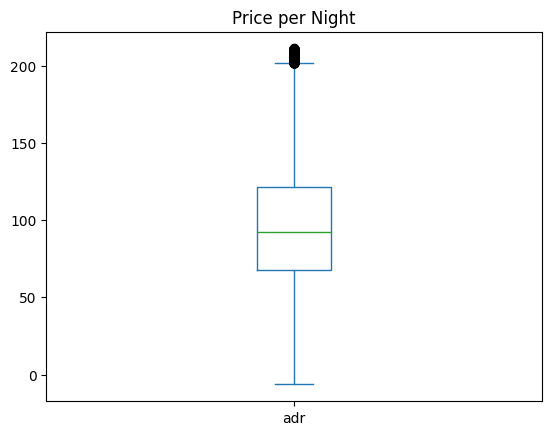

In [26]:
df['adr'].plot(kind='box', title='Price per Night')

In [27]:
print ("Descriptive stats night cancelled")
print("mean = ", df['is_canceled'].mean())
print("median = ", df['is_canceled'].median())

print("skew = ", df['is_canceled'].skew())
print("kurtosis = ", df['is_canceled'].kurt())

Descriptive stats night cancelled
mean =  0.36986253968528593
median =  0.0
skew =  0.5391382385218827
kurtosis =  -1.7093595345247412


<Axes: title={'center': 'Arrival Month'}, xlabel='arrival_date_month'>

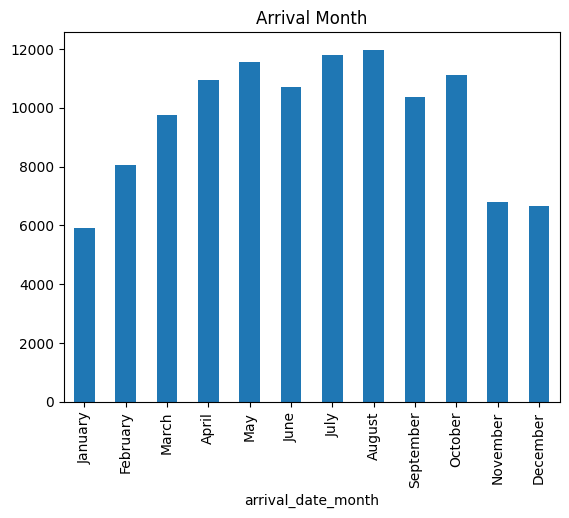

In [34]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df.loc[:, 'arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)
df['arrival_date_month'].value_counts().sort_index().plot(kind='bar', title='Arrival Month')

### ✍️ Your Response:
- **Variable 1 –** Summary and insights: When looking at price per night the average amount appears to be just under $100, after removing outliers it appers that even when it is most expensive the price only doubles and the opposite is also true, sometimes it looks like they are giving away rooms.  
- **Variable 2 –** Summary and insights: On average, it looks like nearly 1/3 of all rooms booked end up getting cancelled. With a median of 0 though we can assume that there is still a good proportion of people who don't cancel.  
- **Variable 3 –** Summary and insights: Then when looking at the number of people who stay per month we can see that the summer through fall are the busiest times during the year with a slight dip in June. This shows that the majority of our locations we are analyzing are likely in warmer climates and people go there for vacation.


## 5. Bivariate Analysis

Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

### In your markdown:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?



<Axes: title={'center': 'Average nightly price by Month'}, xlabel='arrival_date_month'>

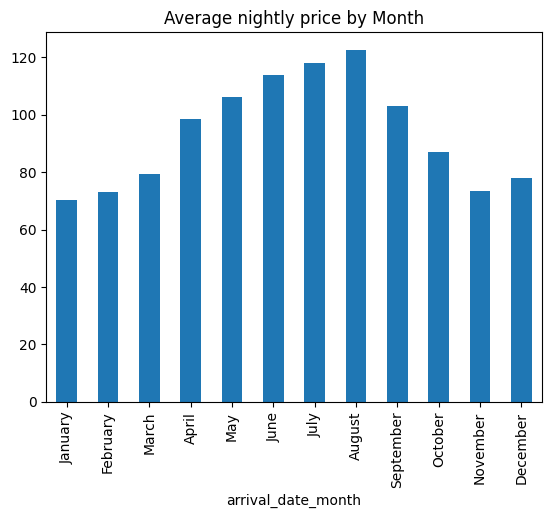

In [40]:
df.groupby('arrival_date_month', observed=True)['adr'].mean().plot(kind='bar', title='Average nightly price by Month')

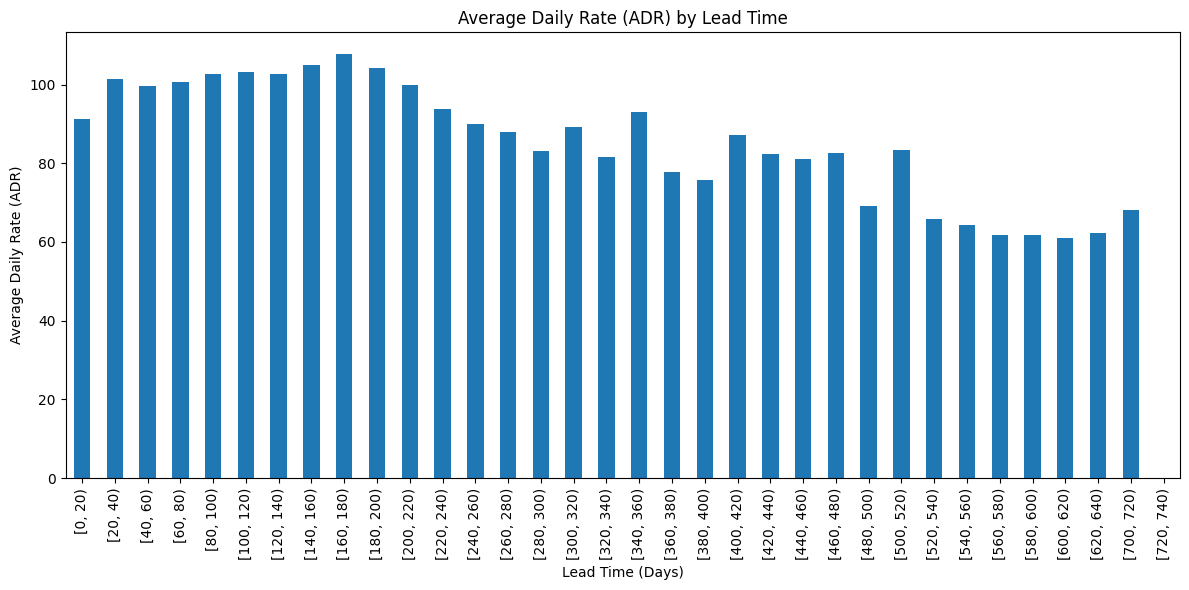

In [46]:
# Bin lead time into intervals of 20
df_copy = df.copy()
df_copy['lead_time_binned'] = pd.cut(df_copy['lead_time'], bins=range(0, df_copy['lead_time'].max() + 20, 20), right=False)

# Calculate the average adr for each bin
adr_by_lead_time_bin = df_copy.groupby('lead_time_binned', observed=True)['adr'].mean()

# Create the bar plot
plt.figure(figsize=(12, 6))
adr_by_lead_time_bin.plot(kind='bar')
plt.title('Average Daily Rate (ADR) by Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### ✍️ Your Response:
- **Relationship 1:** As we can see the summer months into the early fall are the most expensive months. This aligns with what we learned earlier in relation to the busiest months and it aligns with what we might expect.  
- **Relationship 2:** On average the further out you book a room the cheaper the price will be. The biggest exception to this though is last minute bookings.We may expect this as a hotel would want to fill every room possible and if it is last seccond they may offer a lower rate.


## 6. Problem Complexity and Analytics Framing

Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### In your markdown:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response:
1. I am looking at the relationship between averge nightly price and month.
2. We would primarily be looking at variability as we can figure out how consistent the price is by month and in turn connect that with the frequency of visitors per month.
3. Predictive Analytics may be the most helpful in this situation. By using historical data we can build a model that may help us figure out the price per room and in turn find expected revenue for a particular month and other key statistics.



## 7. Final Takeaways and Recommendations

Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

- Identify your top 2–3 insights or patterns
- Connect each to a stakeholder need or business goal
- Make one recommendation based on the analysis

### In your markdown:
1. What patterns or trends stood out?
2. How do they connect to stakeholder goals?
3. What recommendation would you make based on this analysis?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response:

1. The biggest trend that stood out is the relationship between the number of rooms booked and the average nightly price by month. Furthermore, the relationship between lead time and nightly price is very interesting.

2. Our stakeholders want lower priced hotels. Knowing that if they book as far in advance as possible they can save money. Furthermore, knowing what times of the year are the busiest they can get a better understanding of how much they might pay for a night, especially those on a budget.

3. By understanding the relationship between the two trends above we can come up with a plan for capitalizing on value as early as possible. One idea: we already know that the further out a hotel is booked the cheaper the price (typically). We can utilize this piece of key information and incentivise people to make bookings as early as possible, particularly in the winter months, to balance out revenues across the year. We know from the time value of money that a dollar is worth more now than it will be in the future, by getting people to book ahead of time for the busiest months we can balance revenues to compensate for the lower nightly price for the "slow" months and in turn capitalize on time value of money.

4. One of my goals earlier in the year was growing my skills in predictive analytics and being able to understand the possible returns on an investment. By figuring out how to capitalize on simple seasonal trends to maximize profits it is growing my understanding and reasoning in relation to predictive statistics.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [48]:
!jupyter nbconvert --to html "assignment_5_PetersonSteven.ipynb"

[NbConvertApp] Converting notebook assignment_5_PetersonSteven.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 479563 bytes to assignment_5_PetersonSteven.html
